# Unit 4- ANOVAs
updated on 4/21/2026


## Demo  1. One-way ANOVA 

One-way ANOVA (Independent samples)：抑郁干预三种方案（placebo, anxifree, joyzepam）， 情绪改善均值检验

1. 零假设
* H0: $\mu_{placebo}=\mu_{anxifree}=\mu_{joyzepam}$ is true
* H1: $\mu_{placebo},\mu_{anxifree},\mu_{joyzepam}$ 至少有两个不相等

2. Python 检验函数：
* penguion.anova(), or DataFrame.anova(), 要求掌握）

3. posthoc 多重比较， 如果接受H1，希望进一步直到两些对的均值存在显著差异
*  penguion.pairwise_tukey ( 要求了解）

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

In [2]:
data=pd.read_csv("drugstudy.csv")
data

,ID,Group,MoodGain
0,1,placebo,0.5
1,2,placebo,0.3
2,3,placebo,0.1
3,4,anxifree,0.6
4,5,anxifree,0.4
5,6,anxifree,0.2
6,7,joyzepam,1.4
7,8,joyzepam,1.7
8,9,joyzepam,1.3
9,10,placebo,0.6


#### Visualizing the data with boxplot

<Axes: xlabel='Group', ylabel='MoodGain'>

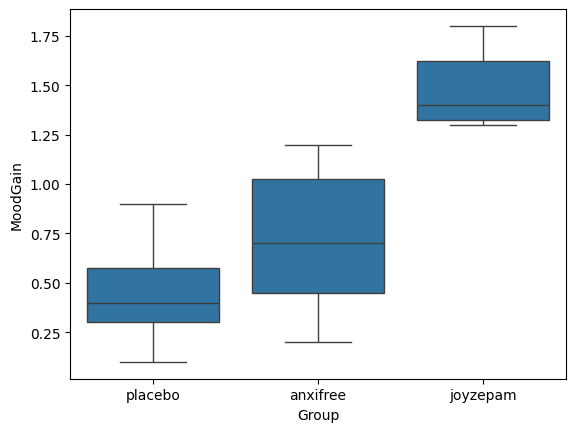

In [3]:
sns.boxplot(x="Group",y="MoodGain",data=data)

### ANOVA函数：pinguion包 

In [4]:
import pingouin as pg
aov=data.anova(dv='MoodGain', between="Group",detailed=True)
print(aov.round(6))

   Source        SS  DF        MS          F     p_unc       np2
0   Group  3.453333   2  1.726667  18.610778  0.000086  0.712762
1  Within  1.391667  15  0.092778        NaN       NaN       NaN


In [5]:
aov=pg.anova(dv="MoodGain",between="Group",data=data,detailed=True)
print(aov)

   Source        SS  DF        MS          F     p_unc       np2
0   Group  3.453333   2  1.726667  18.610778  0.000086  0.712762
1  Within  1.391667  15  0.092778        NaN       NaN       NaN


#### 1-Way ANOVA: Post Hoc 多重检验:
当one-way anova检验结果具有显著差异后，为了确定哪些对比具有差异，需要进行post hoc 比较：

In [6]:
## using pair-wise comparisons using pingouin.pairwise_tukey
pt=data.pairwise_tukey(dv='MoodGain', between='Group')

print(pt.round(4))

          A         B  mean_A  mean_B    diff      se       T  p_tukey  hedges
0  anxifree  joyzepam  0.7167  1.4833 -0.7667  0.1759 -4.3596   0.0015 -2.2417
1  anxifree   placebo  0.7167  0.4500  0.2667  0.1759  1.5164   0.3115  0.7217
2  joyzepam   placebo  1.4833  0.4500  1.0333  0.1759  5.8760   0.0001  3.8205


In [7]:
stats.ttest_ind(data[data.Group=="anxifree"].MoodGain,data[data.Group=="joyzepam"].MoodGain,equal_var=False)

TtestResult(statistic=np.float64(-4.206222496766865), pvalue=np.float64(0.00320741252343862), df=np.float64(7.73064118638938))

In [8]:
data[data.Group=="joyzepam"]

,ID,Group,MoodGain
6,7,joyzepam,1.4
7,8,joyzepam,1.7
8,9,joyzepam,1.3
15,16,joyzepam,1.8
16,17,joyzepam,1.3
17,18,joyzepam,1.4


In [9]:
?pg.pairwise_tukey

Signature: pg.pairwise_tukey(data=None, dv=None, between=None, effsize='hedges')
Docstring:
Pairwise Tukey-HSD post-hoc test.

Parameters
----------
data : :py:class:`pandas.DataFrame`
    DataFrame. Note that this function can also directly be used as a Pandas method, in which
    case this argument is no longer needed.
dv : string
    Name of column containing the dependent variable.
between: string
    Name of column containing the between factor.
effsize : string or None
    Effect size type. Available methods are:

    * ``'none'``: no effect size
    * ``'cohen'``: Unbiased Cohen d
    * ``'hedges'``: Hedges g
    * ``'r'``: Pearson correlation coefficient
    * ``'eta_square'``: Eta-square
    * ``'odds_ratio'``: Odds ratio
    * ``'AUC'``: Area Under the Curve
    * ``'CLES'``: Common Language Effect Size

Returns
-------
stats : :py:class:`pandas.DataFrame`

    * ``'A'``: Name of first measurement
    * ``'B'``: Name of second measurement
    * ``'mean_A'``: Mean of first mea

## Demo 2: One-way Repeated Measures ANOVA ： 
一个班的学生连续四次考试成绩的均值比较数据包括一个班的学生四次考试成绩，
* pinguion.rm_anova()--要求掌握


<Axes: xlabel='Test', ylabel='Scores'>

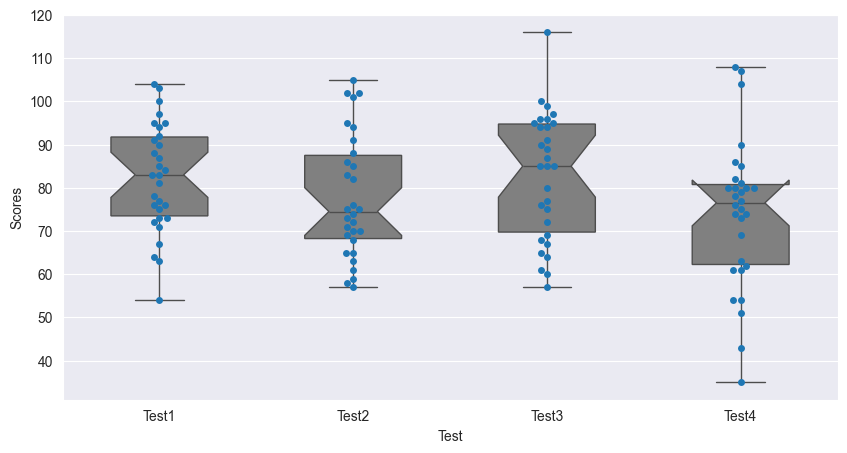

In [10]:
## Crreating the simulated data 
mu=[80,83 ,85,80]
sigma=[15,15,15,15]
n=30
score=[]
test=[]
np.random.seed(100)
for i in np.arange(len(mu)):
    data=np.round(stats.norm.rvs(mu[i],sigma[i],size=n),0)
    score=np.append(score,data)
    test+=["Test"+str(i+1)]*n
data=pd.DataFrame({"Scores":score,"Test":test,"Sub_id":list(np.arange(n)+1)*4})    
##let's visulize the data
sns.set_style("darkgrid")
plt.figure(figsize=(10,5))

sns.swarmplot(x="Test",y="Scores",data=data)
#sns.violinplot(x="Test",y="Scores",data=data,linewidth=1,color="grey",alpha=0.2,inner="quartile",bw=0.2)
sns.boxplot(x="Test",y="Scores",data=data,linewidth=1,color="grey",width=0.5,notch=True)

In [11]:
data.head(31)

,Scores,Test,Sub_id
0,54.0,Test1,1
1,85.0,Test1,2
2,97.0,Test1,3
3,76.0,Test1,4
4,95.0,Test1,5
5,88.0,Test1,6
6,83.0,Test1,7
7,64.0,Test1,8
8,77.0,Test1,9
9,84.0,Test1,10


#### One-way Repeated measures ANOVA: pingouin.rm_anova

In [12]:
import pingouin as pg
aov = pg.rm_anova(data=data, dv='Scores', subject="Sub_id",within='Test', detailed=True)
print(aov)


  Source            SS  DF          MS         F     p_unc       ng2       eps
0   Test   1542.758333   3  514.252778  2.720667  0.049308  0.058073  0.911321
1  Error  16444.491667  87  189.017146       NaN       NaN       NaN       NaN


#### Posthoc 多重比较 for 1-Way repeated measure ANOVA

In [13]:
mc=data.pairwise_ttests(dv="Scores",within="Test",subject="Sub_id",padjust="bonf")
print(mc.round(4))

  Contrast      A      B  Paired  Parametric       T   dof alternative  \
0     Test  Test1  Test2    True        True  1.3860  29.0   two-sided   
1     Test  Test1  Test3    True        True -0.1419  29.0   two-sided   
2     Test  Test1  Test4    True        True  2.7913  29.0   two-sided   
3     Test  Test2  Test3    True        True -1.3180  29.0   two-sided   
4     Test  Test2  Test4    True        True  0.9284  29.0   two-sided   
5     Test  Test3  Test4    True        True  2.3106  29.0   two-sided   

    p_unc  p_corr p_adjust   BF10  hedges  
0  0.1763  1.0000     bonf  0.461  0.3341  
1  0.8882  1.0000     bonf  0.196 -0.0339  
2  0.0092  0.0551     bonf  4.838  0.5487  
3  0.1978  1.0000     bonf  0.426 -0.3418  
4  0.3609  1.0000     bonf  0.288  0.2367  
5  0.0282  0.1690     bonf  1.901  0.5450  


e:\anaconda3\envs\med_env\lib\site-packages\pingouin\pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


In [14]:
aov=data.anova(dv='Scores', between="Test",detailed=True)
print(aov)

   Source            SS   DF          MS         F     p_unc       np2
0    Test   1542.758333    3  514.252778  2.383924  0.072872  0.058073
1  Within  25023.166667  116  215.716954       NaN       NaN       NaN


## Demo 3: Two-way ANOVA

In [15]:
data=pd.read_csv("drugstudy2.csv")
data.head()

,Subject,Drug,Therapy,MoodGain
0,1,placebo,no.therapy,0.5
1,2,placebo,no.therapy,0.3
2,3,placebo,no.therapy,0.1
3,4,anxifree,no.therapy,0.6
4,5,anxifree,no.therapy,0.4


In [16]:
import pingouin as pg
aov=data.anova(dv='MoodGain', between=["Drug","Therapy"],detailed=True)
print(aov.round(6))

           Source        SS  DF        MS          F     p_unc       np2
0            Drug  3.453333   2  1.726667  31.714286  0.000016  0.840909
1         Therapy  0.467222   1  0.467222   8.581633  0.012617  0.416956
2  Drug * Therapy  0.271111   2  0.135556   2.489796  0.124602  0.293269
3        Residual  0.653333  12  0.054444        NaN       NaN       NaN


In [17]:
posthoc=pg.pairwise_ttests(dv="MoodGain", between=["Drug","Therapy"],padjust="bonf",data=data)
print(posthoc.round(4))

         Contrast      Drug         A           B Paired Parametric       T  \
0            Drug         -  anxifree    joyzepam  False       True -4.2062   
1            Drug         -  anxifree     placebo  False       True  1.3542   
2            Drug         -  joyzepam     placebo  False       True  7.1687   
3         Therapy         -       CBT  no.therapy  False       True  1.3068   
4  Drug * Therapy  anxifree       CBT  no.therapy  False       True  3.8000   
5  Drug * Therapy  joyzepam       CBT  no.therapy  False       True  0.1715   
6  Drug * Therapy   placebo       CBT  no.therapy  False       True  1.4412   

    dof alternative   p_unc  p_corr p_adjust     BF10  hedges  
0  10.0   two-sided  0.0018  0.0054     bonf   17.947 -2.2417  
1  10.0   two-sided  0.2055  0.6165     bonf    0.814  0.7217  
2  10.0   two-sided  0.0000  0.0001     bonf  475.231  3.8205  
3  16.0   two-sided  0.2098     NaN      NaN    0.732  0.5867  
4   4.0   two-sided  0.0191  0.0573     bonf   

e:\anaconda3\envs\med_env\lib\site-packages\pingouin\pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


## Demo 4: Two way repeated measure ANOVA (两因素重复测量方差分析）
招募了8名被试（4名青年，4名老年人），进行了一项心理学测试，在三种干扰因素下（如干扰（闭眼），简单干扰，复杂干扰刺激），分别检测被试的心理测试成绩（Scores), 整个过程重复两次（Day1, Day2)。利用重复测量方差分析，研究：


（1）三个不同干扰因素下是否有不同作用？
（2）两天的测试有无差异？
（3）干扰因素的影响在两次重复测量中是否相同？

In [18]:
data=pd.read_csv("anovademo_new.csv")
data.head()

,Test_Order,Distractions,Scores,Subjects,Age
0,Day1,Closed Eyes,8,1,Yong
1,Day1,Closed Eyes,7,2,Yong
2,Day1,Closed Eyes,8,3,Yong
3,Day1,Closed Eyes,7,4,Yong
4,Day1,Closed Eyes,6,5,Old


#### 正态性和方差齐性的检查

In [19]:
## Checking the normality of the data, and the homogeneity of the variance
norm_A = pg.normality(data=data, dv='Scores', group='Test_Order', method='shapiro')
print(norm_A)

norm_B = pg.normality(data=data, dv='Scores', group='Distractions', method='shapiro')
print(norm_B)

data['AB'] = data['Test_Order'].astype(str) + '_' + data['Distractions'].astype(str)
norm_AB = pg.normality(data=data, dv='Scores', group='AB')
print(norm_AB)

homoscedasticityA = pg.homoscedasticity(data=data, dv='Scores', group='Test_Order', method='levene')
print(homoscedasticityA)
homoscedasticityB = pg.homoscedasticity(data=data, dv='Scores', group='Distractions', method='levene')
print(homoscedasticityB)
homoscedasticityAB = pg.homoscedasticity(data=data, dv='Scores', group='AB', method='levene')
print(homoscedasticityAB)





                   W      pval  normal
Test_Order                            
Day1        0.953879  0.328051    True
Day2        0.910829  0.036762   False
                            W      pval  normal
Distractions                                   
Closed Eyes          0.920089  0.169242    True
Simple Distraction   0.938224  0.327825    True
Complex Distraction  0.919934  0.168273    True
                                 W      pval  normal
AB                                                  
Day1_Closed Eyes          0.897413  0.273806    True
Day1_Simple Distraction   0.931989  0.534351    True
Day1_Complex Distraction  0.876758  0.175310    True
Day2_Closed Eyes          0.882123  0.197317    True
Day2_Simple Distraction   0.862885  0.128273    True
Day2_Complex Distraction  0.897271  0.272992    True
           W      pval  equal_var
levene  2.07  0.156991       True
               W     pval  equal_var
levene  1.810345  0.17531       True
               W      pval  equal_var


In [20]:
aov=pg.rm_anova(dv="Scores",within=["Test_Order","Distractions"],subject="Subjects",data=data,correction=True,detailed=True)
print(aov)

                      Source         SS  ddof1  ddof2         MS          F  \
0                 Test_Order  21.333333      1      7  21.333333  17.230769   
1               Distractions  75.875000      2     14  37.937500  22.015544   
2  Test_Order * Distractions   2.541667      2     14   1.270833   1.552727   

      p_unc  p_GG_corr       ng2       eps  
0  0.004290   0.004290  0.171237  1.000000  
1  0.000048   0.000402  0.423587  0.720883  
2  0.246011   0.249743  0.024025  0.852997  


<Axes: xlabel='Distractions', ylabel='Scores'>

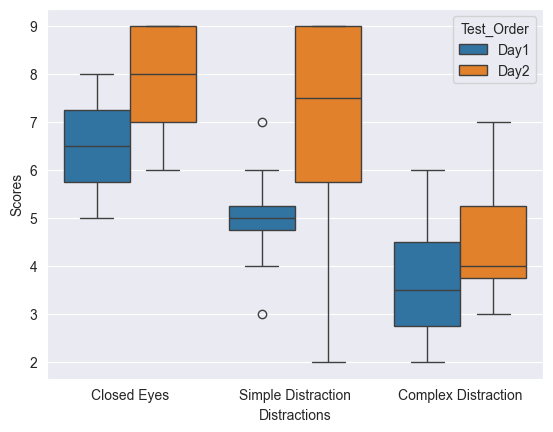

In [21]:
sns.boxplot(hue="Test_Order",y="Scores",x="Distractions",data=data)


## Demo 5: Two-way Mixed ANOVA(本课程不做要求）

#### Mixed ANOVA（本课程不做要求）: 当既有between 因素，又有winthin因素。 比如招募男性和女性志愿者，分别在三种状态(state)，这时候如果要研究性别, 状态及其交互作用，那么性别是组间因素， 状态是组内因素。可以利用pg.mixed_anova来分析

In [22]:
aov=pg.mixed_anova(dv="Scores",within="Distractions",between="Age",subject="Subjects",data=data,correction=True)
print(aov)

         Source         SS  DF1  DF2         MS          F     p_unc  \
0           Age  15.041667    1    6  15.041667   6.242075  0.046628   
1  Distractions  37.937500    2   12  18.968750  19.303887  0.000178   
2   Interaction   0.270833    2   12   0.135417   0.137809  0.872624   

   p_GG_corr       np2       eps sphericity   W_spher   p_spher  
0        NaN  0.509887       NaN        NaN       NaN       NaN  
1   0.000402  0.762882  0.720883       True  0.612813  0.230136  
2        NaN  0.022453       NaN        NaN       NaN       NaN  


## 问题1: 1-Way ANOVA 课后复习题 （4月21日更新）
One-way repeated measure ANOVA
6个中风后语言障碍的病人，分别进行了三种语言测试任务： Speak(说), Conceptual（概念）, Syntax（句法规则），
每个人测试十次，下面的表格是每个病人，每种测试任务下成功的次数，请检验三种任务完成是否具有显著差异？



#### 0. 导入数据 

In [23]:
aphasia=pd.read_csv("aphasia.csv")
aphasia.head()

,Subject,Test,Score,Unnamed: 3
0,1,Speech,8,NaN
1,2,Speech,7,NaN
2,3,Speech,9,NaN
3,4,Speech,5,NaN
4,5,Speech,6,NaN


<Axes: xlabel='Test', ylabel='Score'>

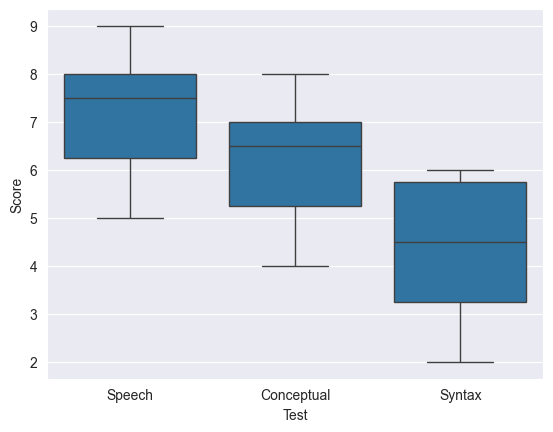

In [24]:
sns.boxplot(data=aphasia, x='Test',y='Score')

#### 1. 正态性检验 pg.normality

In [25]:
## normaility test with pg.normality
pg.normality(aphasia, dv="Score", group="Test")

,W,pval,normal
Test,,,
Speech,0.958012,0.804296,True
Conceptual,0.958012,0.804296,True
Syntax,0.919945,0.504963,True


#### 2. 方差球性检验 pg.sphericity

In [26]:
## test of sphericity with pg.sphericity
pg.sphericity(data=aphasia,dv="Score",within="Test",subject="Subject") 


SpherResults(spher=True, W=np.float64(0.8485783727479649), chi2=np.float64(0.6567713293648831), dof=2, pval=np.float64(0.720085254695584))

#### 3. RM-ANOVA pg.rm_anova

In [27]:
aov = pg.rm_anova(data=aphasia, dv='Score', within='Test', subject="Subject",detailed=True,correction=True)
print(aov)

  Source         SS  DF         MS         F     p_unc  p_GG_corr       ng2  \
0   Test  24.777778   2  12.388889  6.925466  0.012956   0.018022  0.414498   
1  Error  17.888889  10   1.788889       NaN       NaN        NaN       NaN   

        eps sphericity   W_spher   p_spher  
0  0.868492       True  0.848578  0.720085  
1       NaN        NaN       NaN       NaN  


#### 4. post-hoc pairwise 检验 pg.pairwise_tests
如果1-way repeated measure ANOVA 显示了显著的主效应，再用posthoc多重比较,看看具体哪些组间有差异，采用Bonferroni 进行p值校正， 函数：pengouin.pairwise_ttests

Effect size : Hedges’ g 的大小怎么解释？经验性的解释门槛和 Cohen’s d 差不多（只是一个“更校正的 d”）：
- 约 0.2：小效应（small）
- 约 0.5：中等效应（medium）
- 约 0.8：大效应（large）

In [28]:
posthoc=pg.pairwise_ttests(data=aphasia, dv="Score", within="Test", subject="Subject", padjust="bonf")
print(posthoc.round(4))

  Contrast           A       B  Paired  Parametric       T  dof alternative  \
0     Test  Conceptual  Speech    True        True -1.4639  5.0   two-sided   
1     Test  Conceptual  Syntax    True        True  2.6073  5.0   two-sided   
2     Test      Speech  Syntax    True        True  3.1142  5.0   two-sided   

    p_unc  p_corr p_adjust   BF10  hedges  
0  0.2031  0.6093     bonf  0.783 -0.6271  
1  0.0478  0.1435     bonf  2.157  1.0886  
2  0.0264  0.0793     bonf  3.337  1.6824  


e:\anaconda3\envs\med_env\lib\site-packages\pingouin\pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


#### APA 汇报格式
在本研究中，采用单因素重复测量方差分析考察测验类型对成绩的影响。结果表明，测验类型的主效应显著，**F**(2, 10) = 6.93，*p* = .013，广义效应量 η²₍G₎ = .41，且球形性假设成立（*W* = 0.85，*p* = .72，ε = 0.87）。被试在口语条件下得分最高（*M* = 7.17，*SD* = 1.47），其次为概念条件（*M* = 6.17，*SD* = 1.47），句法条件得分最低（*M* = 4.33，*SD* = 1.63）。采用 Bonferroni 校正的配对比较显示，各条件间差异在校正后均未达到显著水平（校正后 *p* 均 > .05），尽管效应量显示口语与概念条件相较于句法条件存在较大的差异趋势。

## 问题2: ANOVA （4月21日更新）

#### 药效的单因素方差分析分析

#### 0. 导入数据

In [29]:
drug=pd.read_csv("DrugDose-New.csv")
drug.head()

,Unnamed: 0,Scores,Group
0,0,3.302234,Ctr
1,1,5.889875,Ctr
2,2,7.370054,Ctr
3,3,4.194075,Ctr
4,4,8.739496,Ctr


<Axes: xlabel='Group', ylabel='Scores'>

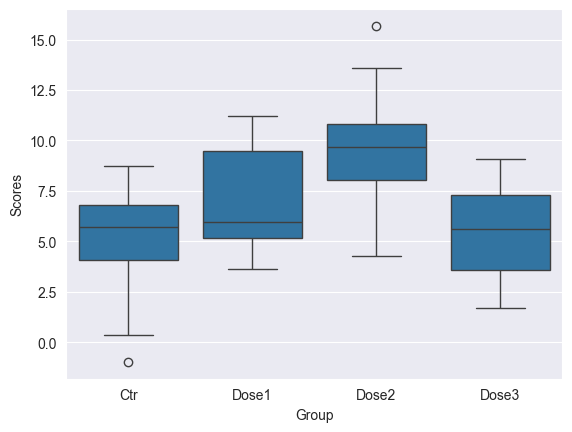

In [30]:
sns.boxplot(data=drug,x='Group',y='Scores')

#### 1. 正态性检验

In [31]:
pg.normality(drug, dv="Scores", group="Group",method="shapiro")

,W,pval,normal
Group,,,
Ctr,0.928609,0.260091,True
Dose1,0.915511,0.164480,True
Dose2,0.975765,0.932370,True
Dose3,0.954349,0.595332,True


#### 2. 方差齐性检验

In [32]:
pg.homoscedasticity(drug, dv="Scores", group="Group",method="levene" )

,W,pval,equal_var
levene,0.122408,0.946516,True


In [ ]:
?pg.welch_anova
#方差不齐用这个

Signature: pg.welch_anova(data=None, dv=None, between=None)
Docstring:
One-way Welch ANOVA.

Parameters
----------
data : :py:class:`pandas.DataFrame`
    DataFrame. Note that this function can also directly be used as a
    Pandas method, in which case this argument is no longer needed.
dv : string
    Name of column containing the dependent variable.
between : string
    Name of column containing the between factor.

Returns
-------
aov : :py:class:`pandas.DataFrame`
    ANOVA summary:

    * ``'Source'``: Factor names
    * ``'ddof1'``: Numerator degrees of freedom
    * ``'ddof2'``: Denominator degrees of freedom
    * ``'F'``: F-values
    * ``'p_unc'``: uncorrected p-values
    * ``'np2'``: Partial eta-squared

See Also
--------
anova : One-way and N-way ANOVA
rm_anova : One-way and two-way repeated measures ANOVA
mixed_anova : Two way mixed ANOVA
kruskal : Non-parametric one-way ANOVA

Notes
-----
From Wikipedia:

*It is named for its creator, Bernard Lewis Welch, and is an adap

#### 3. ANOVA
- 方差齐： pg.anova; 
- 方差不齐： pg.welch_anova

In [33]:
aov=pg.anova(dv="Scores",between="Group",data=drug,detailed=True)
print(aov.round(4))

   Source        SS  DF       MS       F   p_unc     np2
0   Group  187.9449   3  62.6483  8.8573  0.0001  0.3218
1  Within  396.0922  56   7.0731     NaN     NaN     NaN


In [34]:
aov=pg.welch_anova(dv="Scores",between="Group",data=drug)
print(aov.round(4))

  Source  ddof1   ddof2       F   p_unc     np2
0  Group      3  30.969  7.8072  0.0005  0.3218


#### 4. Post-hoc test (时候检验)   

In [35]:
posthoc=pg.pairwise_ttests(data=drug, dv="Scores", between="Group", padjust="bonf")
print(posthoc.round(4))

  Contrast      A      B  Paired  Parametric       T   dof alternative  \
0    Group    Ctr  Dose1   False        True -2.0159  28.0   two-sided   
1    Group    Ctr  Dose2   False        True -4.2708  28.0   two-sided   
2    Group    Ctr  Dose3   False        True -0.2856  28.0   two-sided   
3    Group  Dose1  Dose2   False        True -2.4040  28.0   two-sided   
4    Group  Dose1  Dose3   False        True  1.9181  28.0   two-sided   
5    Group  Dose2  Dose3   False        True  4.3611  28.0   two-sided   

    p_unc  p_corr p_adjust     BF10  hedges  
0  0.0535  0.3210     bonf    1.522 -0.7162  
1  0.0002  0.0012     bonf  115.511 -1.5173  
2  0.7773  1.0000     bonf    0.355 -0.1015  
3  0.0231  0.1385     bonf    2.747 -0.8541  
4  0.0653  0.3921     bonf    1.329  0.6815  
5  0.0002  0.0010     bonf  141.951  1.5494  


e:\anaconda3\envs\med_env\lib\site-packages\pingouin\pairwise.py:30: UserWarning: pairwise_ttests is deprecated, use pairwise_tests instead.
  warnings.warn("pairwise_ttests is deprecated, use pairwise_tests instead.", UserWarning)


#### 5. APA结果报告

对四种药物剂量条件（Ctr、Dose1、Dose2、Dose3）下的得分进行单因素方差分析，
事先检验确认各组数据满足正态性（Shapiro-Wilk 检验，所有 *p*s > .05）及方差齐性（Levene 检验，*F* < 1）假设。分析结果表明，药物剂量主效应显著，*F*(3, 56) = 8.86, *p* < .001, η² = .32。Tukey HSD 事后检验显示，Dose2 组（*M* = 9.56, *SD* = 2.94）的得分显著高于对照组 Ctr（*M* = 5.13, *SD* = 2.75；*p* < .001, *d* = 1.56）和Dose3 组（*M* = 5.39, *SD* = 2.26；*p* < .001, *d* = 1.59），其余各组间均无显著差异（所有 *p*s > .05）。